Data Loading

In [88]:
import pandas as pd

df = pd.read_excel("../data/Forecasting Case- Study.xlsx")

print(df.head())

print(df.columns)

print(df.info())

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages
Index(['State', 'Date', 'Total', 'Category'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     8084 non-null   object 
 1   Date      8084 non-null   object 
 2   Total     8084 non-null   float64
 3   Category  8084 non-null   object 
dtypes: float64(1), object(3)
memory usage: 252.8+ KB
None


Data Cleaning

In [89]:
# Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Check missing values
print(df.isnull().sum())

# Display first rows
print(df.head())

State       0
Date        0
Total       0
Category    0
dtype: int64
             State       Date        Total   Category
0          Alabama 2019-01-12  109574036.0  Beverages
24      New Mexico 2019-01-12   34731555.3  Beverages
25        New York 2019-01-12  240815212.2  Beverages
26  North Carolina 2019-01-12  182341458.0  Beverages
27            Ohio 2019-01-12  194452564.4  Beverages


FEATURE ENGINEERING

In [90]:
#STEP 1 — CREATE LAG FEATURES
# Lag Features

df['lag_1'] = df['Total'].shift(1)

df['lag_7'] = df['Total'].shift(7)

df['lag_30'] = df['Total'].shift(30)

print(df[['Total', 'lag_1', 'lag_7', 'lag_30']].head(35))

          Total        lag_1        lag_7       lag_30
0   109574036.0          NaN          NaN          NaN
24   34731555.3  109574036.0          NaN          NaN
25  240815212.2   34731555.3          NaN          NaN
26  182341458.0  240815212.2          NaN          NaN
27  194452564.4  182341458.0          NaN          NaN
28   77743069.7  194452564.4          NaN          NaN
29   58257574.4   77743069.7          NaN          NaN
30  197064569.3   58257574.4  109574036.0          NaN
32   97713917.2  197064569.3   34731555.3          NaN
23   30014723.1   97713917.2  240815212.2          NaN
33   14701327.2   30014723.1  182341458.0          NaN
35  472848726.3   14701327.2  194452564.4          NaN
36   42799315.6  472848726.3   77743069.7          NaN
37   10140664.3   42799315.6   58257574.4          NaN
38  153170304.3   10140664.3  197064569.3          NaN
39  100959341.5  153170304.3   97713917.2          NaN
40   38228549.6  100959341.5   30014723.1          NaN
41   84291

In [91]:
from sklearn.preprocessing import LabelEncoder

# Encode State column
state_encoder = LabelEncoder()

df['state_encoded'] = state_encoder.fit_transform(
    df['State']
)

print(df[['State', 'state_encoded']].head())

             State  state_encoded
0          Alabama              0
24      New Mexico             24
25        New York             25
26  North Carolina             26
27            Ohio             27


In [92]:
#STEP 2 — ROLLING MEAN & STD
# Rolling Mean and Standard Deviation

df['rolling_mean_7'] = df['Total'].rolling(window=7).mean()

df['rolling_std_7'] = df['Total'].rolling(window=7).std()

print(df[['rolling_mean_7', 'rolling_std_7']].head(15)) 

    rolling_mean_7  rolling_std_7
0              NaN            NaN
24             NaN            NaN
25             NaN            NaN
26             NaN            NaN
27             NaN            NaN
28             NaN            NaN
29    1.282736e+08   7.802133e+07
30    1.407723e+08   8.145855e+07
32    1.497698e+08   7.054039e+07
23    1.196554e+08   7.018969e+07
33    9.570682e+07   7.374577e+07
35    1.354777e+08   1.602310e+08
36    1.304857e+08   1.628524e+08
37    1.236119e+08   1.673622e+08
38    1.173413e+08   1.649565e+08


In [93]:
#STEP 3 — DAY OF WEEK & MONTH
# Date Features

df['day_of_week'] = df['Date'].dt.dayofweek

df['month'] = df['Date'].dt.month

print(df[['Date', 'day_of_week', 'month']].head())

         Date  day_of_week  month
0  2019-01-12            5      1
24 2019-01-12            5      1
25 2019-01-12            5      1
26 2019-01-12            5      1
27 2019-01-12            5      1


In [94]:
#HolidayFlags
import holidays

us_holidays = holidays.US()

df['holiday_flag'] = df['Date'].apply(
    lambda x: 1 if x in us_holidays else 0
)

print(df[['Date', 'holiday_flag']].head(20))

         Date  holiday_flag
0  2019-01-12             0
24 2019-01-12             0
25 2019-01-12             0
26 2019-01-12             0
27 2019-01-12             0
28 2019-01-12             0
29 2019-01-12             0
30 2019-01-12             0
32 2019-01-12             0
23 2019-01-12             0
33 2019-01-12             0
35 2019-01-12             0
36 2019-01-12             0
37 2019-01-12             0
38 2019-01-12             0
39 2019-01-12             0
40 2019-01-12             0
41 2019-01-12             0
42 2019-01-12             0
34 2019-01-12             0


In [95]:
#STEP 5 — REMOVE EMPTY VALUES
# Remove rows with NaN values (due to lag and rolling features)
df = df.dropna()

print(df.head())

print(df.shape)

       State       Date        Total   Category        lag_1        lag_7  \
8   Illinois 2019-01-12  167913696.8  Beverages  198967926.5   16673878.0   
9    Indiana 2019-01-12  117489218.5  Beverages  167913696.8   58049432.2   
10      Iowa 2019-01-12   60702757.5  Beverages  117489218.5  444766890.6   
1    Arizona 2019-01-12  109101594.6  Beverages   60702757.5   89816716.3   
12  Kentucky 2019-01-12   91340443.0  Beverages  109101594.6   49715400.0   

         lag_30  state_encoded  rolling_mean_7  rolling_std_7  day_of_week  \
8   109574036.0              8    1.953347e+08   1.531146e+08            5   
9    34731555.3              9    2.038261e+08   1.457009e+08            5   
10  240815212.2             10    1.489598e+08   1.070297e+08            5   
1   182341458.0              1    1.517148e+08   1.054908e+08            5   
12  194452564.4             12    1.576612e+08   9.980271e+07            5   

    month  holiday_flag  
8       1             0  
9       1       

TRAIN / VALIDATION SPLIT

In [96]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

print("Train Shape:", train.shape)

print("Test Shape:", test.shape)

Train Shape: (6443, 13)
Test Shape: (1611, 13)


4 Models

In [73]:
#SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train SARIMA model
sarima_model = SARIMAX(
    train['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

# Forecast
sarima_pred = sarima_result.forecast(steps=len(test))

print(sarima_pred.head())

C:\Users\Sai\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Sai\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Sai\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Sai\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is availabl

6443    2.083742e+08
6444    2.096850e+08
6445    2.223854e+08
6446    2.309613e+08
6447    2.148916e+08
Name: predicted_mean, dtype: float64


In [74]:
#PROPHET MODEL
from prophet import Prophet

# Prophet needs specific column names
prophet_df = df[['Date', 'Total']].copy()

prophet_df.columns = ['ds', 'y']

# Train Prophet model
prophet_model = Prophet()

prophet_model.fit(prophet_df)

# Create future dates (8 weeks = 56 days)
future = prophet_model.make_future_dataframe(periods=56)

# Predict future
forecast = prophet_model.predict(future)

# Show predictions
print(forecast[['ds', 'yhat']].tail())

22:23:45 - cmdstanpy - INFO - Chain [1] start processing
22:23:46 - cmdstanpy - INFO - Chain [1] done processing


            ds          yhat
239 2024-01-24  2.264505e+08
240 2024-01-25  2.007078e+08
241 2024-01-26  2.069116e+08
242 2024-01-27  2.139390e+08
243 2024-01-28  2.111286e+08


In [75]:
# XGBOOST MODEL

from xgboost import XGBRegressor

# Feature columns
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month',
    'holiday_flag',
    'state_encoded'
]

# Training data
X_train = train[features]
y_train = train['Total']

# Testing data
X_test = test[features]
y_test = test['Total']

# Create model
xgb_model = XGBRegressor()

# Train model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Display first 5 predictions
print(xgb_pred[:5])

[9.4536040e+07 1.6254726e+08 2.7681322e+08 2.0342392e+07 7.4761824e+07]


In [76]:
# LSTM MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# Convert to numpy arrays
X_train_lstm = np.array(X_train)
y_train_lstm = np.array(y_train)

X_test_lstm = np.array(X_test)

# Reshape into 3D format
X_train_lstm = X_train_lstm.reshape(
    (X_train_lstm.shape[0], 1, X_train_lstm.shape[1])
)

X_test_lstm = X_test_lstm.reshape(
    (X_test_lstm.shape[0], 1, X_test_lstm.shape[1])
)

# Build model
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        50,
        activation='relu',
        input_shape=(1, X_train_lstm.shape[2])
    )
)

lstm_model.add(Dense(1))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

# Train model
lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=32,
    verbose=1
)

# Predictions
lstm_pred = lstm_model.predict(X_test_lstm)

# Display predictions
print(lstm_pred[:5])

C:\Users\Sai\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 26537303694376960.0000
Epoch 2/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 21039653213700096.0000
Epoch 3/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 19992999748435968.0000
Epoch 4/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 19475252178321408.0000
Epoch 5/5
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 19175018931945472.0000
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
[[1.3610245e+08]
 [1.3091418e+08]
 [1.2983845e+08]
 [1.2220097e+08]
 [1.1627862e+08]]


IMPORT METRICS

In [77]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

4 model Evaluations

In [78]:
# SARIMA Metrics

sarima_mae = mean_absolute_error(
    test['Total'],
    sarima_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test['Total'],
        sarima_pred
    )
)

sarima_mape = np.mean(
    np.abs(
        (test['Total'] - sarima_pred)
        / test['Total']
    )
) * 100

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAPE:", sarima_mape)

SARIMA MAE: 151508134.9978481
SARIMA RMSE: 198930129.97458726
SARIMA MAPE: 184.06176951186654


In [79]:
# XGBoost Metrics

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test - xgb_pred)
        / y_test
    )
) * 100

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAPE:", xgb_mape)

XGBoost MAE: 22993678.250357408
XGBoost RMSE: 32365279.75227429
XGBoost MAPE: 18.702342620735067


In [80]:
# Flatten predictions
lstm_pred_flat = lstm_pred.flatten()

# LSTM Metrics

lstm_mae = mean_absolute_error(
    y_test,
    lstm_pred_flat
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lstm_pred_flat
    )
)

lstm_mape = np.mean(
    np.abs(
        (y_test - lstm_pred_flat)
        / y_test
    )
) * 100

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

LSTM MAE: 132686489.35862818
LSTM RMSE: 185348796.98855054
LSTM MAPE: 137.07680981796048


In [81]:
# Prophet Metrics

prophet_mae = mean_absolute_error(
    test['Total'],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test['Total'],
        prophet_pred
    )
)

prophet_mape = np.mean(
    np.abs(
        (test['Total'] - prophet_pred)
        / test['Total']
    )
) * 100

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)
print("Prophet MAPE:", prophet_mape)

Prophet MAE: 139477118.03327027
Prophet RMSE: 194869988.6289122
Prophet MAPE: 162.49454172946912


FINAL COMPARISON NETWEEN 4 MODELS

In [82]:
import pandas as pd

results = pd.DataFrame({

    'Model': [
        'SARIMA',
        'Prophet',
        'XGBoost',
        'LSTM'
    ],

    'MAE': [
        sarima_mae,
        prophet_mae,
        xgb_mae,
        lstm_mae
    ],

    'RMSE': [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse,
        lstm_rmse
    ],

    'MAPE': [
        sarima_mape,
        prophet_mape,
        xgb_mape,
        lstm_mape
    ]
})

print(results)

     Model           MAE          RMSE        MAPE
0   SARIMA  1.515081e+08  1.989301e+08  184.061770
1  Prophet  1.394771e+08  1.948700e+08  162.494542
2  XGBoost  2.299368e+07  3.236528e+07   18.702343
3     LSTM  1.326865e+08  1.853488e+08  137.076810


AUTOMATIC MODEL SELECTION

In [83]:
# Select best model automatically

best_model_row = results.loc[
    results['RMSE'].idxmin()
]

print("Best Model:")
print(best_model_row)


Best Model:
Model            XGBoost
MAE      22993678.250357
RMSE     32365279.752274
MAPE           18.702343
Name: 2, dtype: object


Save Best Model

In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgb_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


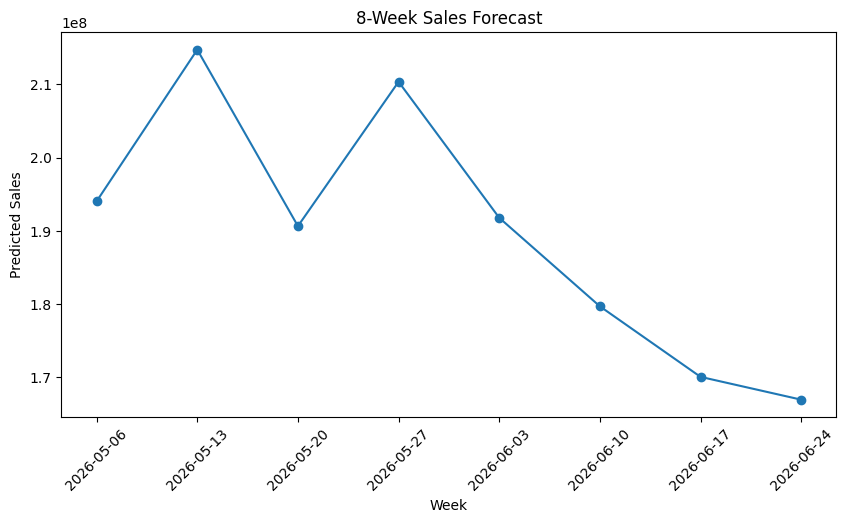

In [85]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Example forecast values
forecast_values = [
    194039264,
    214726432,
    190652144,
    210347664,
    191788592,
    179710832,
    170085568,
    166975216
]

# Generate future week dates
weeks = []

for i in range(8):

    future_date = (
        datetime.now() + timedelta(weeks=i)
    ).strftime("%Y-%m-%d")

    weeks.append(future_date)

# Plot graph
plt.figure(figsize=(10,5))

plt.plot(
    weeks,
    forecast_values,
    marker='o'
)

plt.title("8-Week Sales Forecast")

plt.xlabel("Week")

plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)

plt.show()

In [86]:
print(df.columns)

Index(['State', 'Date', 'Total', 'Category', 'lag_1', 'lag_7', 'lag_30',
       'state_encoded', 'rolling_mean_7', 'rolling_std_7', 'day_of_week',
       'month', 'holiday_flag'],
      dtype='object')


In [ ]:
df.to_excel(
    "../data/final_feature_engineered_data.xlsx",
    index=False
)